# Volumetric Analysis for Particle Detection
Try to align the particle locations reported from the portal inspection to the raw data volumes.

A couple of caveats we need to account for:
1. The volumes are not cropped as they are in the portal.
2. The volumes are not aligned as they are in the portal - so there is some angular deviations between the portal and raw images.

**Some Notes:**
Inspecting M50L-01 from the portal the distance from the bottom of the can to the edge of the image is about 0.44mm or about 27 voxels

The results in the ground truth table are the z-location in 1mm slab increments, meaning the value are +/- 61/2 voxels.

# Notebook Config

In [109]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import toml

sys.path.insert(0, str(Path.cwd().parent))
from cfg_data import AnalysisBase

plt.style.use("dark_background")


def get_cell_index(cfg: dict, volume_name: str) -> int:
    cell_idx = -1
    for n, cell in enumerate(cfg["cell"]):
        if cell["name"] == volume_name:
            cell_idx = n
            break
    return cell_idx


def find_candidates(
    df: pd.DataFrame,
    z_loc: float,
    cy: float,
    cx: float,
    delta_z_mean: float,
    delta_z_std: float,
    delta_y_mean: float,
    delta_y_std: float,
    delta_x_mean: float,
    delta_x_std: float,
    slab_thickness: list[int],
    low_thresholds: list[float],
):
    """
    Given the z,y,x location of a particle, find candidate matches in the dataframe using standard tolerances
    """
    z_min = z_loc / voxel_size_mm + delta_z_mean - 3 * delta_z_std
    z_max = z_loc / voxel_size_mm + delta_z_mean + 3 * delta_z_std
    df_ = df[(df["peak_z"] > z_min) & (df["peak_z"] < z_max)]

    # The portal image is upside down from the raw representations
    y_min = (1425 - cy) + delta_y_mean - 3 * delta_y_std
    y_max = (1425 - cy) + delta_y_mean + 3 * delta_y_std
    df_ = df_[(df_["peak_y"] > y_min) & (df_["peak_y"] < y_max)]

    x_min = cx + delta_x_mean - 3 * delta_x_std
    x_max = cx + delta_x_mean + 3 * delta_x_std
    df_ = df_[(df_["peak_x"] > x_min) & (df_["peak_x"] < x_max)]

    df_ = df_[df_["slab_thickness"].isin(slab_thickness)]
    df_ = df_[df_["low_threshold_scale"].isin(low_thresholds)]
    return df_


def commit_match(
    df_matches: pd.DataFrame,
    match_log_path: Path,
    portal_idx: int,
    serial_number: str,
    z_portal: float,
    y_center: float,
    x_center: float,
    z_raw: float | None,
    y_raw: float | None,
    x_raw: float | None,
    ml_prob: float | None = None,
    particle_class: float | None = None,
    notes: str = "",
    overwrite: bool = False,
) -> pd.DataFrame:
    """Append (or replace) one resolved GT point in the match log and persist it to disk."""
    # Coerce None -> np.nan up front so the numeric columns stay float64 instead of
    # widening to object dtype when concatenated onto the existing log.
    z_raw, y_raw, x_raw, ml_prob, particle_class = (
        np.nan if v is None else v
        for v in (z_raw, y_raw, x_raw, ml_prob, particle_class)
    )
    status = "no_match" if pd.isna(z_raw) else "matched"

    existing = df_matches[df_matches["portal_idx"] == portal_idx]
    if len(existing) and not overwrite:
        print(
            f"portal_idx {portal_idx} already has {len(existing)} row(s) logged -- "
            f"pass overwrite=True to replace them instead:"
        )
        print(existing)
        return df_matches

    if overwrite:
        df_matches = df_matches[df_matches["portal_idx"] != portal_idx]

    row = dict(
        portal_idx=portal_idx,
        serial_number=serial_number,
        z_portal=z_portal,
        y_center=y_center,
        x_center=x_center,
        status=status,
        z_raw=z_raw,
        y_raw=y_raw,
        x_raw=x_raw,
        ml_prob=ml_prob,
        particle_class=particle_class,
        notes=notes,
    )
    df_matches = pd.concat([df_matches, pd.DataFrame([row])], ignore_index=True)
    df_matches = df_matches.sort_values("portal_idx").reset_index(drop=True)
    df_matches.to_csv(match_log_path, index=False)

    print(f"Committed portal_idx={portal_idx} ({serial_number}), status={status}")
    # .item() unwraps numpy scalars (np.float64(...), np.int64(...)) to plain Python
    # types so the printed dict isn't cluttered with numpy's verbose repr.
    print({k: (v.item() if hasattr(v, "item") else v) for k, v in row.items()})
    return df_matches


cfg_path = Path("../config.toml")
cfg = toml.load(cfg_path)

DATA_ROOT = Path("../Data")
DATA_ROOT_GT = DATA_ROOT / "ground_truth"
DATA_ROOT_EXP = DATA_ROOT / "experiments"
df_ground_truth = pd.read_csv(DATA_ROOT_GT / "2026_07_23_particles_query_for_jim.csv")
df_candidates = pd.read_csv(DATA_ROOT_EXP / "combined_candidates.csv")

match_log_path = DATA_ROOT_GT / "matches.csv"
df_matches = pd.read_csv(match_log_path)
voxel_size_mm = 0.0164


/var/folders/29/803dzgr92dx7_lk8zb5y_j7r0000gn/T/ipykernel_49527/376005458.py:129: DtypeWarning: Columns (53,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_candidates = pd.read_csv(DATA_ROOT_EXP / "combined_candidates.csv")


## Raw alignment utilities
 - should be applied to each volume before matching coordinates

In [110]:
def get_alignment_info(volume_idx: int) -> dict[str, float]:
    """
    For a raw volume, estimate the transformation mapping raw (z,x,y) coordinates into aligned coordinates.

    Returns a dictionary containing the slopes, intercepts, and rotation matrix for aligning the volume.
    """
    global cfg_path  # assumed defined
    z_min = 250
    z_max = 4001
    volume_object = AnalysisBase(cfg_path, vol_index=volume_idx, exp_index=0)
    vol = volume_object.vol[:, :, :]
    _, h, w = vol.shape
    axial_x = vol[z_min:z_max, :, w // 2]
    axial_y = vol[z_min:z_max, h // 2, :]

    def get_edges(img: np.ndarray) -> np.ndarray:
        """Get the edge of the image, assuming it's an axial view"""
        edge = cv2.Sobel(cv2.GaussianBlur(img, (5, 5), 0), cv2.CV_32F, 1, 0, ksize=3)
        h, w = img.shape
        edge[:, w // 8 : -w // 8] = 0
        edge = np.abs(edge)
        edge = edge > (edge.max() / 2)
        return edge

    def find_mask_left_edge(mask: np.bool_):
        valid = mask.any(axis=1)
        rows = np.flatnonzero(valid)
        cols = mask[valid].argmax(axis=1)
        return np.column_stack((rows, cols))

    def find_mask_right_edge(mask: np.bool_):
        edge = find_mask_left_edge(np.fliplr(mask))
        row, cols = edge[:, 0], edge[:, 1]
        cols = mask.shape[1] - 1 - cols
        return np.column_stack((row, cols))

    def get_centerline_fit(img: np.ndarray):
        edge = get_edges(img)
        left_edge = find_mask_left_edge(edge)
        right_edge = find_mask_right_edge(edge)
        if len(left_edge) != img.shape[0] or len(right_edge) != img.shape[0]:
            raise ValueError("Edge detection failed for some slices.")

        centerline = (left_edge + right_edge) / 2
        slope, intercept = np.polyfit(centerline[:, 0], centerline[:, 1], deg=1)
        return slope, intercept

    def centerline_rotation_matrix(slope_x, slope_y) -> np.ndarray:
        """Rotation mapping the centerline direction onto the z-axis."""

        source = np.array([1.0, slope_x, slope_y])
        source /= np.linalg.norm(source)

        target = np.array([1.0, 0.0, 0.0])

        rotation_axis = np.cross(source, target)
        sin_angle = np.linalg.norm(rotation_axis)
        cos_angle = np.dot(source, target)

        if sin_angle < 1e-12:
            return np.eye(3)

        K = np.array(
            [
                [0.0, -rotation_axis[2], rotation_axis[1]],
                [rotation_axis[2], 0.0, -rotation_axis[0]],
                [-rotation_axis[1], rotation_axis[0], 0.0],
            ]
        )

        return np.eye(3) + K + K @ K * ((1.0 - cos_angle) / sin_angle**2)

    results = {}

    slope, intercept = get_centerline_fit(axial_x)
    results["slope_x"] = slope
    results["intercept_x"] = intercept - slope * z_min

    slope, intercept = get_centerline_fit(axial_y)
    results["slope_y"] = slope
    results["intercept_y"] = intercept - slope * z_min

    rotation_matrix = centerline_rotation_matrix(results["slope_x"], results["slope_y"])
    results["rotation_matrix"] = rotation_matrix
    return results


def raw_to_aligned(
    z: float, x: float, y: float, alignment: dict[str, float]
) -> np.ndarray:
    """
    Transforms the raw unaligned coordinates to coordinates aligned to the cylindrical volume's primary axis

    Args:
        z (float): The raw z-coordinate.
        x (float): The raw x-coordinate.
        y (float): The raw y-coordinate.
        alignment (dict[str, float]): Dictionary containing alignment parameters, including slopes, intercepts, and rotation matrix.

    Returns:
        np.ndarray: The aligned coordinates as a NumPy array.
    """
    bx = alignment["intercept_x"]
    by = alignment["intercept_y"]
    rot_matrix = alignment["rotation_matrix"]
    ctr = np.array([0, bx, by])
    point = np.array([z, x, y])
    aligned_point = rot_matrix @ (point - ctr)
    return aligned_point + ctr


def aligned_to_raw(
    z: float,
    x: float,
    y: float,
    alignment: dict,
) -> np.ndarray:
    """Transform aligned (z, x, y) coordinates back to raw coordinates."""

    bx = float(alignment["intercept_x"])
    by = float(alignment["intercept_y"])
    rot_matrix = np.asarray(alignment["rotation_matrix"])

    ctr = np.array([0.0, bx, by])
    aligned_point = np.array([z, x, y], dtype=float)

    raw_point = rot_matrix.T @ (aligned_point - ctr)
    return raw_point + ctr

# Match Refining
Identifying GT from the portal and matching to the candidate locations suffer from impreciseness of the labels, the labeling of closely spaced particles, and the further imprecisness of the labels produced by bounding-box center.<br>
<br>
Vertical z-locations from the portal labels are only precise within a slab of 1mm which is about 61 voxels. Further, since the slices in the portal are maxxed over the 1mm, particles within that slab that are not laterally separated will merge onto one another - so there can be multiple candidate particles assigned to one label OR the labeled particle might seem larger and brighter because of this merging. Potential merging can be composed of several low-contrast regions that are not individually picked up by the detection algorithm.<br>
<br>
Visual inspection of candidate particles to portal labels requires some visual inspection. 
<br>
Also note that some portal labels are actually duplicates and should be dropped.

## Find the portal labels that are duplicates
We can use this information to eliminate false-positives when we begin to look for duplicate raw matches

In [111]:
# Find the duplicate portal entries - these are not exact matches but can vary in x and y so we'll need a distance tolerance on those
TOL_LATERAL = 3.0
exact_cols = ["serial_number", "z_portal"]
x_col, y_col = "x_center", "y_center"
working = df_matches.reset_index(names="row_id")
pairs = working.merge(working, on=exact_cols, suffixes=("_1", "_2"))
pairs = pairs[pairs["row_id_1"] < pairs["row_id_2"]]
pairs["distance"] = np.hypot(
    pairs[f"{x_col}_1"] - pairs[f"{x_col}_2"],
    pairs[f"{y_col}_1"] - pairs[f"{y_col}_2"],
)
duplicate_pairs = (
    pairs[pairs["distance"] < TOL_LATERAL]
    .sort_values("portal_idx_1")
    .reset_index(drop=True)
)
drop_cols = [
    "status_1",
    "status_2",
    "notes_1",
    "notes_2",
    "ml_prob_1",
    "ml_prob_2",
    "status_1",
    "status_2",
    "particle_class_1",
    "particle_class_2",
    "row_id_1",
    "row_id_2",
]
df_portal_duplicate_pairs = duplicate_pairs.drop(columns=drop_cols)
df_portal_duplicate_pairs.head(100)
print(f"Found {len(df_portal_duplicate_pairs)} duplicate portal pairs")

Found 10 duplicate portal pairs


## Find the isolated particles in all volumes.
The isolated particles will allow us to compute more robust linear transformation between the raw coordinates and the portal coordinates.

In [112]:
isolated_gt_particle_idxs = []
TOL_SEPARATED = 510
for index, row in df_ground_truth.iterrows():
    snum = row["serial_number"]
    zpos = row["z_position"]
    working = df_ground_truth[
        (df_ground_truth["serial_number"] == snum)
        & (df_ground_truth["z_position"] == zpos)
    ]
    if len(working) == 1:
        isolated_gt_particle_idxs.append(index)
        continue

    # Now if there are multiple items, then retain iff it is well separated laterally
    working = working[working.index != index]
    x = row["x_center"]
    y = row["y_center"]

    is_separated = True
    for _, other_row in working.iterrows():
        _x = other_row["x_center"]
        _y = other_row["y_center"]
        dist = np.linalg.norm(np.array([x, y]) - np.array([_x, _y]))
        if dist < TOL_SEPARATED:
            is_separated = False
            break

    if is_separated:
        isolated_gt_particle_idxs.append(index)

df_isolated_gt_particles = df_ground_truth.loc[isolated_gt_particle_idxs].copy()


### Accumulate the portal and corresponding raw locations 
These will be used later to define expected matching locations

In [113]:
portal_xy_pairs_dict = {}
raw_zxy_pairs_dict = {}
for serial_number in df_ground_truth["serial_number"].unique():
    working_gt = df_isolated_gt_particles
    working_gt = working_gt[working_gt["serial_number"] == serial_number]
    working_m = df_matches[df_matches["serial_number"] == serial_number]
    for _, row in working_gt.iterrows():
        x = row["x_center"]
        y = row["y_center"]
        if serial_number not in portal_xy_pairs_dict:
            portal_xy_pairs_dict[serial_number] = []
        matches = working_m[(working_m["x_center"] == x) & (working_m["y_center"] == y)]
        if len(matches) == 0:
            continue
        portal_xy_pairs_dict[serial_number].append((x, y))
        x_raw = matches["x_raw"].values[0]
        y_raw = matches["y_raw"].values[0]
        z_raw = matches["z_raw"].values[0]
        if serial_number not in raw_zxy_pairs_dict:
            raw_zxy_pairs_dict[serial_number] = []
        raw_zxy_pairs_dict[serial_number].append((z_raw, x_raw, y_raw))

    portal_xy_pairs_dict[serial_number] = np.array(portal_xy_pairs_dict[serial_number])
    raw_zxy_pairs_dict[serial_number] = np.array(raw_zxy_pairs_dict[serial_number])
    # print(f"Volume {serial_number} has {len(working_gt)} isolated ground truth particles")

## Assess candidate particles that were multiply matched to a label. 
The multiple matches will need to be rectified.

- We can ignore the 10 multiple raw matches if there are duplicate portal labels
  - These duplicates are encapsulated in the dataframe df_portal_duplicate_pairs

**Notes:**
- Duplicate particle on M50L-12 is a particle that straddles the z-boundary in the portal - the matches are valid!
- Duplicate particle on M50L-18 are two particles well zeparated in z. One must occur at the bottom of one stack and the other at the top - they appear to be separated by 104 slices.

### Find all the duplicated raw matches

In [114]:
_cols = ["serial_number", "z_raw", "y_raw", "x_raw"]
df_duplicate_raw_matches = df_matches[df_matches.duplicated(subset=_cols, keep=False)]

# Remove the duplicates due to nan - implying there was no particle identified in the candidate DB
df_duplicate_raw_matches = df_duplicate_raw_matches.dropna(subset=["z_raw"])
print(f"Found {len(df_duplicate_raw_matches)} duplicate raw matches")


Found 32 duplicate raw matches


### Remove the duplicates that are associated with a portal duplicate

In [115]:
idxs_to_remove = []
for idx, row in df_duplicate_raw_matches.iterrows():
    pairs = df_portal_duplicate_pairs
    common = (pairs["serial_number"] == row["serial_number"]) & (
        pairs["z_portal"] == row["z_portal"]
    )
    portal_y = row["y_center"]
    portal_x = row["x_center"]

    matches_1 = (
        common & (pairs["y_center_1"] == portal_y) & (pairs["x_center_1"] == portal_x)
    )
    matches_2 = (
        common & (pairs["y_center_2"] == portal_y) & (pairs["x_center_2"] == portal_x)
    )

    if (matches_1 | matches_2).any():
        idxs_to_remove.append(idx)


df_duplicate_raw_matches = df_duplicate_raw_matches.drop(index=idxs_to_remove)
print(
    f"Removed {len(idxs_to_remove)} duplicated rows, results of length {len(df_duplicate_raw_matches)}"
)
df_duplicate_raw_matches.head(100)

Removed 17 duplicated rows, results of length 15


,portal_idx,serial_number,z_portal,y_center,x_center,status,z_raw,y_raw,x_raw,ml_prob,particle_class,notes
94,94,M50L-12,30.0,391.6,720.5,matched,1994.0,981.0,756.0,NaN,NaN,same particle as in z=31-straddles boundary
95,95,M50L-12,31.0,392.2,721.4,matched,1994.0,981.0,756.0,NaN,NaN,same particle as in z=30-straddles boundary
228,228,M50L-21,52.0,334.3,1175.2,matched,3274.0,1019.0,1215.0,0.907142,-1.0,NaN
229,229,M50L-21,52.0,354.5,1188.9,matched,3295.0,997.0,1229.0,0.698494,3.0,NaN
230,230,M50L-21,52.0,367.3,1195.9,matched,3274.0,1019.0,1215.0,0.907142,-1.0,NaN
231,231,M50L-21,52.0,382.4,1204.8,matched,3295.0,997.0,1229.0,0.698494,3.0,NaN
233,233,M50L-21,52.0,511.8,1255.8,matched,3324.0,853.0,1289.0,0.982372,3.0,NaN
235,235,M50L-21,53.0,555.1,1265.3,matched,3410.0,811.0,1298.0,0.995128,3.0,NaN
236,236,M50L-21,53.0,537.5,1262.2,matched,3324.0,853.0,1289.0,0.982372,3.0,NaN
245,245,M50L-21,54.0,394.2,1209.1,matched,3445.0,980.0,1238.0,0.562784,3.0,NaN


## Review the duplicates and fix
We need to do this volume by volume

In [116]:
unique_volumes = df_duplicate_raw_matches["serial_number"].unique()
# Remove volume 12 - we have already established that this is OK since it is from a duplicate portal entry
unique_volumes = set(unique_volumes) - {"M50L-12"}
unique_volumes = list(unique_volumes)

vol_idx = 0
working_duplicates = df_duplicate_raw_matches[
    df_duplicate_raw_matches["serial_number"] == unique_volumes[vol_idx]
]


### Find the alignment transformation from raw coords to portal coords

In [117]:
alignment = get_alignment_info(20)

Using metadata file /Users/jim/Documents/GitHub/particles/Data/volumes/M50L-06.xtekhelixct instead of /Users/jim/Documents/GitHub/particles/Data/volumes/M50L-21.xtekhelixct, exists=True


In [118]:
raw_zxy_pairs = raw_zxy_pairs_dict[unique_volumes[vol_idx]]
portal_xy_pairs = portal_xy_pairs_dict[unique_volumes[vol_idx]]

aligned_zxy_pairs = []
for raw_pair in raw_zxy_pairs:
    aligned_pair = raw_to_aligned(*raw_pair, alignment=alignment)
    aligned_zxy_pairs.append(aligned_pair)

In [119]:
aligned_xs = [a_zxy[1] for a_zxy in aligned_zxy_pairs]
portal_xs = [p_xy[0] for p_xy in portal_xy_pairs]
aligned_ys = [a_zxy[2] for a_zxy in aligned_zxy_pairs]
portal_ys = [p_xy[1] for p_xy in portal_xy_pairs]

m_x, b_x = np.polyfit(portal_xs, aligned_xs, 1)
m_y, b_y = np.polyfit(portal_ys, aligned_ys, 1)

In [120]:
def portal_to_raw(portal_x, portal_y, aligned_z):
    """Helper function to convert portal coordinates to raw coordinates.

    Args:
        portal_x (float): The portal x-coordinate.
        portal_y (float): The portal y-coordinate.
        aligned_z (float): The aligned z-coordinate.

    Returns:
        np.ndarray: The raw coordinates corresponding to the given portal coordinates.
    """
    aligned_x = m_x * np.array(portal_x) + b_x
    aligned_y = m_y * np.array(portal_y) + b_y
    return aligned_to_raw(aligned_z, aligned_x, aligned_y, alignment)

#### Spot check the alignment mapping

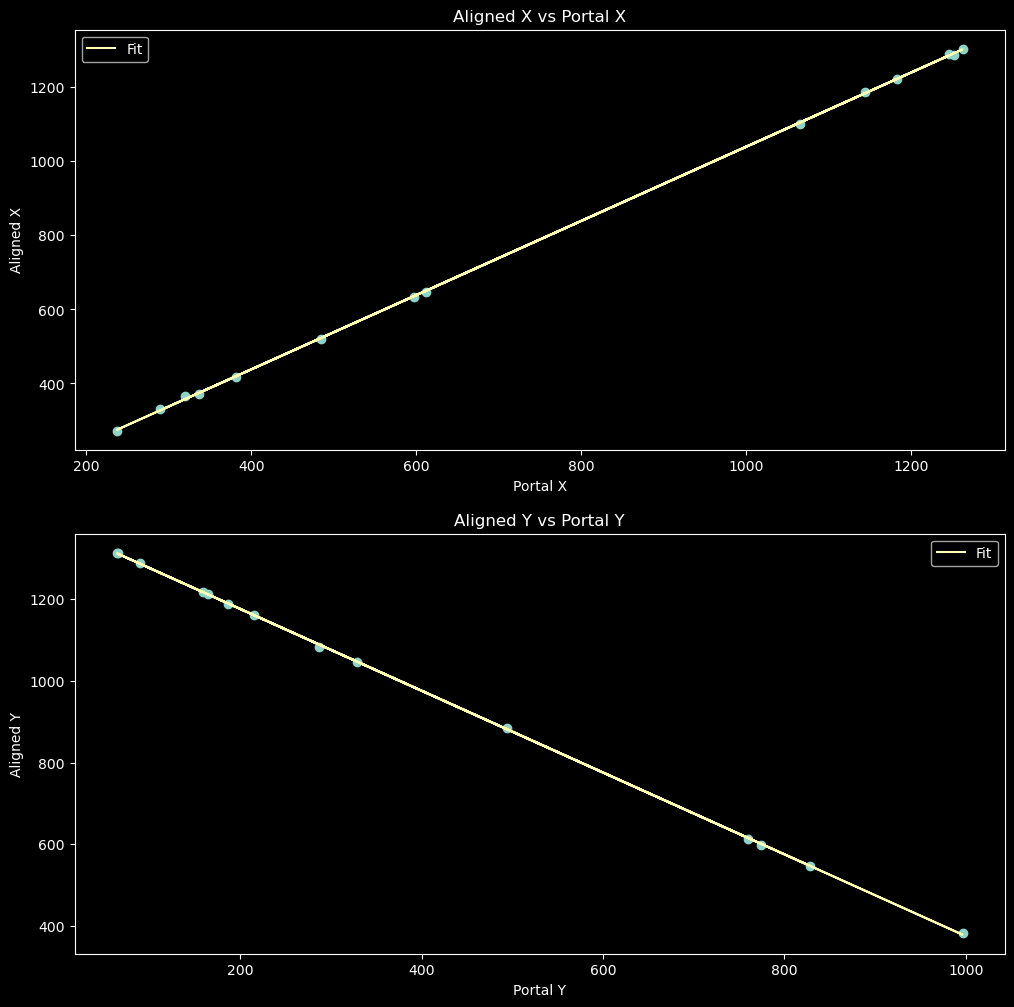

In [121]:
# Spot-check the alignments
plt.figure(figsize=(12, 12))
plt.subplot(2, 1, 1)
plt.plot(portal_xs, aligned_xs, "o")
plt.plot(portal_xs, m_x * np.array(portal_xs) + b_x, "-", label="Fit")
plt.title("Aligned X vs Portal X")
plt.xlabel("Portal X")
plt.ylabel("Aligned X")
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(portal_ys, aligned_ys, "o")
plt.plot(portal_ys, m_y * np.array(portal_ys) + b_y, "-", label="Fit")
plt.title("Aligned Y vs Portal Y")
plt.xlabel("Portal Y")
plt.ylabel("Aligned Y")
plt.legend()

### Now review the duplicates

In [124]:
working_duplicates = working_duplicates.sort_values(by='z_raw')
working_duplicates.head(60)

,portal_idx,serial_number,z_portal,y_center,x_center,status,z_raw,y_raw,x_raw,ml_prob,particle_class,notes
228,228,M50L-21,52.0,334.3,1175.2,matched,3274.0,1019.0,1215.0,0.907142,-1.0,NaN
230,230,M50L-21,52.0,367.3,1195.9,matched,3274.0,1019.0,1215.0,0.907142,-1.0,NaN
229,229,M50L-21,52.0,354.5,1188.9,matched,3295.0,997.0,1229.0,0.698494,3.0,NaN
231,231,M50L-21,52.0,382.4,1204.8,matched,3295.0,997.0,1229.0,0.698494,3.0,NaN
233,233,M50L-21,52.0,511.8,1255.8,matched,3324.0,853.0,1289.0,0.982372,3.0,NaN
236,236,M50L-21,53.0,537.5,1262.2,matched,3324.0,853.0,1289.0,0.982372,3.0,NaN
235,235,M50L-21,53.0,555.1,1265.3,matched,3410.0,811.0,1298.0,0.995128,3.0,NaN
245,245,M50L-21,54.0,394.2,1209.1,matched,3445.0,980.0,1238.0,0.562784,3.0,NaN
246,246,M50L-21,54.0,382.1,1205.1,matched,3445.0,980.0,1238.0,0.562784,3.0,NaN
261,261,M50L-21,56.0,468.8,1244.0,matched,3544.0,906.0,1272.0,0.096764,3.0,NaN


In [130]:
pos = 3
portal_z = working_duplicates["z_portal"].iloc[pos]
portal_x = working_duplicates["x_center"].iloc[pos]
portal_y = working_duplicates["y_center"].iloc[pos]
print(f"Portal z,y,x: {portal_z}, {portal_y}, {portal_x}")
raw_z = working_duplicates["z_raw"].iloc[pos]
raw_x = working_duplicates["x_raw"].iloc[pos]
raw_y = working_duplicates["y_raw"].iloc[pos]
print(f"Raw z,y,x: {raw_z}, {raw_y}, {raw_x}")
shifted_x = m_x * portal_x + b_x
shifted_y = m_y * portal_y + b_y
pred_z, pred_x, pred_y = aligned_to_raw(raw_z, shifted_x, shifted_y, alignment)
print(f"shifted_y:{shifted_y:.1f}, shifted_x: {shifted_x:.1f}")
print(f"pred_z: {pred_z:.1f}, pred_y: {pred_y:.1f}, pred_x: {pred_x:.1f}")


Portal z,y,x: 52.0, 382.4, 1204.8
Raw z,y,x: 3295.0, 997.0, 1229.0
shifted_y:993.7, shifted_x: 1244.2
pred_z: 3296.7, pred_y: 980.9, pred_x: 1240.2


In [ ]:
print(f"raw_z: {raw_z}, raw_x: {raw_x}, raw_y: {raw_y}")
print(f"pred_z: {pred_z:.1f}, pred_y: {pred_y:.1f}, pred_x: {pred_x:.1f}")


raw_z: 3267.0, raw_x: 1175.0, raw_y: 1074.0
pred_z: 3269.0, pred_x: 1171.6, pred_y: 1078.7


### Scratch area to map portal coords & search through candidate DB

In [ ]:
# Map portal to raw coordinates
portal_z = 44.0
portal_y = 624.7
portal_x = 1274
print(f"Portal z,y,x: {portal_z}, {portal_y}, {portal_x}")
raw_z = 2836
raw_y = 700
raw_x = 1310
print(f"Raw z,y,x: {raw_z}, {raw_y}, {raw_x}")
shifted_x = m_x * portal_x + b_x
shifted_y = m_y * portal_y + b_y
pred_z, pred_x, pred_y = aligned_to_raw(raw_z, shifted_x, shifted_y, alignment)
print(f"shifted_y:{shifted_y:.1f}, shifted_x: {shifted_x:.1f}")
print(f"pred_z: {pred_z:.1f}, pred_y: {pred_y:.1f}, pred_x: {pred_x:.1f}")

Portal z,y,x: 44.0, 624.7, 1274
1274 1313.4773062688978
624.7 750.7704347838804
Raw z,y,x: 2836, 700, 1310
shifted_y:750.8, shifted_x: 1313.5
pred_z: 2836.9, pred_y: 739.8, pred_x: 1310.0


In [76]:
# Map raw coordinates to portal
raw_z = 3297
raw_y = 1081
raw_x = 1181

aligned_z, aligned_y, aligned_x = raw_to_aligned(raw_z, raw_y, raw_x, alignment)
portal_y = 1.0 / m_y * (aligned_y - b_y)
portal_x = 1.0 / m_x * (aligned_x - b_x)
print(f"Aligned z,y,x: {aligned_z}, {aligned_y}, {aligned_x}")
print(f"Portal y,x: {portal_y}, {portal_x}")

Aligned z,y,x: 3294.7132448610373, 1084.9908151536347, 1193.7700121288308
Portal y,x: 291.283846894103, 1154.4627998617732


In [136]:
df_scratch = df_candidates[df_candidates["volume_name"] == unique_volumes[vol_idx]]
z_min, z_max = 3297 - 70, 3297 + 70
df_scratch = df_scratch[
    (df_scratch["peak_z"] >= z_min) & (df_scratch["peak_z"] <= z_max)
]
margin = 15
x_min, x_max = 1224-margin, 1240+margin
df_scratch = df_scratch[
    (df_scratch["peak_x"] >= x_min) & (df_scratch["peak_x"] <= x_max)
]
y_min, y_max = 980-margin, 1009+margin
df_scratch = df_scratch[
    (df_scratch["peak_y"] >= y_min) & (df_scratch["peak_y"] <= y_max)
]

df_scratch = df_scratch[df_scratch['peak_y'] != 997]
df_scratch.head(100)

,volume_name,experiment_number,peak_z,peak_y,peak_x,particle,n_voxels,n_seed,n_seed_regions,n_seed_total,...,ml_prob,ml_prob_particle_max,ml_prob_max_source_experiment_number,ml_prob_max_source_volume_name,ml_prob_max_source_peak_z,ml_prob_max_source_peak_y,ml_prob_max_source_peak_x,min_fill,max_axial_extent_mm,enforce_shape_gates
19421,M50L-21,18,3328,967,1245,3,15,9,1,9,...,0.650029,0.675472,15.0,M50L-21,3328.0,967.0,1245.0,0.15,0.262,True
42483,M50L-21,19,3328,967,1245,3,13,9,1,9,...,0.453541,0.675472,15.0,M50L-21,3328.0,967.0,1245.0,0.15,0.262,True
81046,M50L-21,0,3328,967,1246,3,17,7,1,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,0.262,True
121587,M50L-21,1,3328,967,1246,3,16,7,1,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,0.262,True
162908,M50L-21,2,3328,967,1246,3,13,7,1,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,0.262,True
196648,M50L-21,3,3328,967,1246,3,20,8,1,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,0.262,True
229852,M50L-21,4,3328,967,1246,3,18,8,1,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,0.262,True
264044,M50L-21,5,3328,967,1246,3,16,8,1,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,0.262,True
286329,M50L-21,6,3328,967,1245,3,18,9,1,9,...,0.672361,0.675472,15.0,M50L-21,3328.0,967.0,1245.0,0.15,0.262,True
309304,M50L-21,7,3328,967,1245,3,18,9,1,9,...,0.672361,0.675472,15.0,M50L-21,3328.0,967.0,1245.0,0.15,0.262,True


In [137]:
_df = df_matches[df_matches['serial_number'] == 'M50L-21']
_df = _df[_df['z_portal'] > 48]
_df.head()

,portal_idx,serial_number,z_portal,y_center,x_center,status,z_raw,y_raw,x_raw,ml_prob,particle_class,notes
212,212,M50L-21,49.0,214.9,1064.9,matched,3149.0,1150.0,1098.0,0.999353,3.0,NaN
213,213,M50L-21,50.0,424.9,1225.9,matched,3212.0,940.0,1259.0,0.808178,3.0,NaN
214,214,M50L-21,50.0,359.5,1191.2,matched,3204.0,1009.0,1222.0,0.992307,3.0,NaN
215,215,M50L-21,50.0,354.8,1188.1,matched,3200.0,1006.0,1224.0,0.995781,3.0,NaN
216,216,M50L-21,51.0,344.5,1181.8,no_match,NaN,NaN,NaN,NaN,NaN,too small above SNR


# Portal Ground Truth to Candidate Database Matching

## Alignment stats from matches.csv

`delta_z/y/x_mean/std` -- the offset between the portal's reported location and the raw
volume's peak location -- are now computed directly from the persisted match log
(`Data/ground_truth/matches.csv`), which is the source of truth going forward. These
values were previously derived from the `particle_raw_dict`/`particle_portal_dict` cell,
which has been retired now that `matches.csv` was checked to reproduce the same stats.


In [ ]:
def _update_alignment_stats():
    df_matches = pd.read_csv(match_log_path)
    matched = df_matches[df_matches["status"] == "matched"]
    # matched = matched[matched['serial_number']=='M50L-23']
    print(
        f"{len(matched)}/{len(df_matches)} entries are 'matched' (rest are confirmed no_match)"
    )

    delta_z = (
        matched["z_raw"].to_numpy() - matched["z_portal"].to_numpy() / voxel_size_mm
    )
    delta_y = matched["y_raw"].to_numpy() - (1425 - matched["y_center"].to_numpy())
    delta_x = matched["x_raw"].to_numpy() - matched["x_center"].to_numpy()

    delta_z_mean, delta_z_std = delta_z.mean(), delta_z.std()
    delta_y_mean, delta_y_std = delta_y.mean(), delta_y.std()
    delta_x_mean, delta_x_std = delta_x.mean(), delta_x.std()

    return (
        df_matches,
        delta_z_mean,
        delta_z_std,
        delta_y_mean,
        delta_y_std,
        delta_x_mean,
        delta_x_std,
    )


(
    df_matches,
    delta_z_mean,
    delta_z_std,
    delta_y_mean,
    delta_y_std,
    delta_x_mean,
    delta_x_std,
) = _update_alignment_stats()

print(f"Mean (z,y,x) = {delta_z_mean:.1f}, {delta_y_mean:.1f}, {delta_x_mean:.1f}")
print(f"Std  (z,y,x) = {delta_z_std:.1f}, {delta_y_std:.1f}, {delta_x_std:.1f}")

## Get a confirmed particle location from GT DB

In [ ]:
def _get_next_portal_location():
    # df_gt = df_ground_truth.copy()
    resolved_idxs = set(df_matches["portal_idx"])
    try:
        portal_idx = (
            next(i for i in df_ground_truth.index if i not in resolved_idxs) - 0
        )
    except:
        print("No more portal locations available.")
        return None, None, None, None, None, None, None
    volume_name = df_ground_truth["serial_number"].iloc[portal_idx]
    df = df_candidates[df_candidates["volume_name"] == volume_name]
    z_loc = df_ground_truth["z_position"].iloc[portal_idx]
    cx = df_ground_truth["x_center"].iloc[portal_idx]
    cy = df_ground_truth["y_center"].iloc[portal_idx]
    cell_idx = get_cell_index(cfg, volume_name)
    volume_data = AnalysisBase(cfg_path, vol_index=cell_idx, exp_index=0)

    print(
        f"portal_idx: {portal_idx} ({len(resolved_idxs)} of {len(df_ground_truth)}/{len(resolved_idxs) / len(df_ground_truth):.2%} already resolved)"
    )
    print("volume file:", volume_name)

    z_to_raw = z_loc / voxel_size_mm + delta_z_mean
    y_to_raw = 1425 - cy + delta_y_mean
    x_to_raw = cx + delta_x_mean
    print("z:", z_loc, round(z_to_raw))
    print("cy:", cy, round(y_to_raw))
    print("cx:", cx, round(x_to_raw))

    return portal_idx, volume_data, volume_name, df, z_loc, cy, cx


portal_idx, volume_data, volume_name, df_volume_candidates, z_loc, cy, cx = (
    _get_next_portal_location()
)

if portal_idx is not None:
    z_to_raw, y_to_raw, x_to_raw = (
        z_loc / voxel_size_mm + delta_z_mean,
        1425 - cy + delta_y_mean,
        cx + delta_x_mean,
    )
    print(
        "cx in mm:",
        round(cx * voxel_size_mm, 2),
        "cy in mm:",
        round(cy * voxel_size_mm, 2),
    )


## Inspect the database for a match

In [ ]:
def _is_raw_already_matched(z_raw, y_raw, x_raw) -> bool:
    tmp_df = df_matches[df_matches["serial_number"] == volume_name]
    tmp_df = tmp_df[
        (tmp_df["z_raw"] == z_raw)
        & (tmp_df["y_raw"] == y_raw)
        & (tmp_df["x_raw"] == x_raw)
    ]
    return len(tmp_df) > 0


print("Portal to raw (z,y,x):", round(z_to_raw), round(y_to_raw), round(x_to_raw))
print(z_loc, cy, cx)
df_ = find_candidates(
    df_volume_candidates,
    z_loc,
    cy,
    cx,
    delta_z_mean,
    delta_z_std,
    delta_y_mean,
    delta_y_std,
    delta_x_mean,
    delta_x_std,
    slab_thickness=[21, 23, 25],
    low_thresholds=[2.5, 2.75, 3.0],
)

if False:
    pad_ = 120
    z_pad_ = 60
    z_min = z_loc / voxel_size_mm + delta_z_mean - 3 * delta_z_std - z_pad_
    z_max = z_loc / voxel_size_mm + delta_z_mean + 3 * delta_z_std + z_pad_
    y_min = (1425 - cy) + delta_y_mean - 3 * delta_y_std - pad_
    y_max = (1425 - cy) + delta_y_mean + 3 * delta_y_std + pad_
    x_min = cx + delta_x_mean - 3 * delta_x_std - pad_
    x_max = cx + delta_x_mean + 3 * delta_x_std + pad_
    # z_min = 3780; z_max=3950; y_min=1200; y_max=1300; x_min=850; x_max=950
    print(
        f"    **** z_min = {z_min:.1f}, z_max = {z_max:.1f}, y_min = {y_min:.1f}, y_max = {y_max:.1f}, x_min = {x_min:.1f}, x_max = {x_max:.1f}"
    )
    df_ = df_volume_candidates.copy()
    df_ = df_[(df_["peak_z"] > z_min) & (df_["peak_z"] < z_max)]
    df_ = df_[(df_["peak_y"] > y_min) & (df_["peak_y"] < y_max)]
    df_ = df_[(df_["peak_x"] > x_min) & (df_["peak_x"] < x_max)]

    df_ = df_[df_["slab_thickness"].isin([21, 23, 25])]
    df_ = df_[
        df_["low_threshold_scale"].isin(
            [
                2.5,
                2.75,
            ]
        )
    ]

# region Drop unnecessary columns
cols = df_.columns
df_.drop(
    columns=[
        # "experiment_number",
        "n_seed_regions",
        "n_seed",
        "z_extent",
        "y_extent",
        "x_extent",
        "fill",
        "centroid_z",
        "centroid_y",
        "centroid_x",
        "normal_z",
        "axis_z",
        "diag",
        "metal_threshold",
        "baseline_method",
        "small_z_bounds",
        "z_pad",
        "high_threshold_scale",
        "peak_offset",
    ],
    inplace=True,
)
# endregion

if len(df_) == 0:
    _z, _y, _x, _prob, _class = None, None, None, None, None
else:
    _loc = 0
    _z = df_["peak_z"].iloc[_loc]
    _y = df_["peak_y"].iloc[_loc]
    _x = df_["peak_x"].iloc[_loc]
    _prob = df_["ml_prob"].iloc[_loc]
    _class = df_["particle"].iloc[_loc]

# print(df_.drop_duplicates(subset=['peak_z']).iloc[0:])
print(df_.iloc[0:])
if _prob is not None:
    print(
        f"This raw coordinate has already been matched? {_is_raw_already_matched(_z, _y, _x)}\n"
        f"Selected particle raw location: z, y, x = {_z}, {_y}, {_x}, prob = {_prob:.4f}, class = {_class}, portal = {z_loc}, {round(cy)}, {round(cx)}"
    )

## Visualize

In [ ]:
def _prep_display():
    window_size = 31
    h, w = volume_data.vol.shape[1:]
    pad = 100 * 5
    z = _z
    y = h - _y
    x = _x
    print("Particle location: z, x, y =", z, x, y)
    row, col = y, x
    col_slice = slice(max(col - pad // 2, 0), min(col + pad // 2 + 1, w))
    row_slice = slice(max(row - pad // 2, 0), min(row + pad // 2 + 1, h))

    radial_slice = volume_data.vol[
        round(z) - window_size // 2 : round(z) + window_size // 2 + 1, :, :
    ].max(axis=0)
    radial_slice = np.flipud(radial_slice)

    radial_slice = cv2.circle(np.ascontiguousarray(radial_slice), (x, y), 20, 128, 2)
    radial_slice = radial_slice[row_slice, col_slice]

    radial_slice = np.clip(radial_slice, 0, 180)
    # radial_slice = cv2.GaussianBlur(radial_slice, (3, 3), 0)
    _min = radial_slice.min()
    _min = 0
    _max = 240
    radial_slice = (radial_slice - _min) / (radial_slice.max() - _min) * 255
    radial_slice = radial_slice.astype(np.uint8)
    return radial_slice


if _z is not None:
    radial_slice = _prep_display()

    # region plotting
    plt.figure(figsize=(10, 10))
    h, w = radial_slice.shape
    plt.imshow(radial_slice[:, :], cmap="gray")
    plt.title(f"Radial Slice at z={round(_z)}/{round(_z) * voxel_size_mm:.1f} mm")
    plt.axis("off")
    plt.show()
    # endregion plotting
else:
    print("Particle not located in candidate database")

## Commit the match

Once the plot above confirms (or rules out) the candidate, log it to `matches.csv`
immediately -- this is the durable record; nothing else needs hand-editing afterwards.

`commit_match()` logs whatever is currently in `_z`/`_y`/`_x`/`_prob`/`_class` (i.e.
whichever candidate you selected via `_loc` in the inspect cell, or `None`s if the query
came back empty). Re-running the "Get a confirmed particle location" cell afterwards
will pick up the next unresolved `portal_idx` automatically.


In [ ]:
df_matches = commit_match(
    df_matches,
    match_log_path,
    portal_idx=portal_idx,
    serial_number=volume_name,
    z_portal=z_loc,
    y_center=cy,
    x_center=cx,
    z_raw=_z,
    y_raw=_y,
    x_raw=_x,
    ml_prob=_prob,
    particle_class=_class,
    notes="",  # "Contrast just below threshold",  # Appears min_seed is only 2",
    # overwrite=True,  # uncomment to correct a previously-committed entry
)

# END OF NOTEBOOK
Anything below here is just scratch work

## Tilt inspection

In [ ]:
from sklearn.linear_model import LinearRegression, RANSACRegressor


def fit_global_centerline(centerline):
    z = centerline[:, 0].astype(float)
    position = centerline[:, 1].astype(float)

    z0 = (z.min() + z.max()) / 2
    slope, center_at_z0 = np.polyfit(z - z0, position, deg=1)

    fitted = center_at_z0 + slope * (z - z0)
    residuals = position - fitted

    return {
        "slope": slope,
        "center_at_z0": center_at_z0,
        "fitted": fitted,
        "residuals": residuals,
    }


def robust_line(points, residual_threshold=2.0):
    # Fit y = slope*x + intercept
    y = points[:, 1].reshape(-1, 1)
    x = points[:, 0].reshape(-1, 1)

    model = RANSACRegressor(
        estimator=LinearRegression(),
        min_samples=2,
        residual_threshold=residual_threshold,
        random_state=0,
    )
    model.fit(x, y)

    return {
        "model": model,
        "outliers": points[~model.inlier_mask_],
        "slope": model.estimator_.coef_[0],
        "intercept": model.estimator_.intercept_,
    }

In [ ]:
z_min, z_max = 250, 4001
volume_object = AnalysisBase(cfg_path=cfg_path, vol_index=0, exp_index=0)
axial_x = volume_object.vol[:, :, volume_object.vol.shape[2] // 2]
axial_y = volume_object.vol[:, volume_object.vol.shape[1] // 2, :]

print(volume_object.vol.shape)

In [ ]:
h, w = axial_x.shape
edge_x = cv2.Sobel(cv2.GaussianBlur(axial_x, (5, 5), 0), cv2.CV_32F, 1, 0, ksize=3)
edge_y = cv2.Sobel(cv2.GaussianBlur(axial_y, (5, 5), 0), cv2.CV_32F, 1, 0, ksize=3)
edge_x[:, w // 8 : -w // 8] = 0
edge_y[:, w // 8 : -w // 8] = 0

edge_x = np.abs(edge_x)
edge_y = np.abs(edge_y)
p90_x = np.percentile(edge_x, 99.5)
p90_y = np.percentile(edge_y, 99.5)
edge_x = edge_x > p90_x
edge_y = edge_y > p90_y

In [ ]:
plt.figure(figsize=(15, 15))
tmp = cv2.cvtColor((axial_x), cv2.COLOR_GRAY2BGR)
# tmp[edge_y] = (0,255,0)
plt.imshow(tmp[2315 - 100 : 2315 + 100, :200], cmap="gray")
plt.plot(71, 100, "rx")
plt.show()

In [ ]:
1 - 2 / 1425

In [ ]:
left_edge_x = find_mask_left_edge(edge_x.astype(np.bool_))
right_edge_x = find_mask_right_edge(edge_x.astype(np.bool_))
left_edge_y = find_mask_left_edge(edge_y.astype(np.bool_))
right_edge_y = find_mask_right_edge(edge_y.astype(np.bool_))

print(f"Length of X left edge/right edge: {len(left_edge_x)}/{len(right_edge_x)}")
print(f"Length of Y left edge/right edge: {len(left_edge_y)}/{len(right_edge_y)}")

In [ ]:
center_line_x = (left_edge_x.astype(float) + right_edge_x) / 2
center_line_y = (left_edge_y.astype(float) + right_edge_y) / 2

In [ ]:
fit_x = fit_global_centerline(center_line_x)
fit_y = fit_global_centerline(center_line_y)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(center_line_x[:, 0], fit_x["residuals"])
axes[0].axhline(0, color="white", linestyle="--")
axes[0].set_title("X-centerline residual")

axes[1].plot(center_line_y[:, 0], fit_y["residuals"])
axes[1].axhline(0, color="white", linestyle="--")
axes[1].set_title("Y-centerline residual")

print(fit_x)
print(fit_y)

In [ ]:
width_x = right_edge_x[:, 1] - left_edge_x[:, 1]
center_x_col = (right_edge_x[:, 1] + left_edge_x[:, 1]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(center_line_x[:, 0], center_x_col)
axes[0].set_title("Estimated centerline")

axes[1].plot(center_line_x[:, 0], width_x)
axes[1].set_title("Apparent cylinder width")

In [ ]:
width_y = right_edge_y[:, 1] - left_edge_y[:, 1]
center_y_col = (right_edge_y[:, 1] + left_edge_y[:, 1]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(center_line_y[:, 0], center_y_col)
axes[0].set_title("Estimated centerline")

axes[1].plot(center_line_y[:, 0], width_y)
axes[1].set_title("Apparent cylinder width")

In [ ]:
cl = center_line_x[:500]  # np.concatenate((center_line_x[:500], center_line_x[:-500]))
pts_z = cl[:, 0][:]
pts_y = cl[:, 1][:]
# The lengths of the y-cut do not run the full length of the cylinder
plt.figure(figsize=(15, 12))
plt.subplot(2, 1, 1)
plt.plot(pts_z, pts_y, label="(z,y) Left Cylinder Points X")
plt.plot(pts_z, 719.1 + pts_z * (-0.002287))
plt.legend()

cl = center_line_y[
    400:600
]  # np.concatenate((center_line_y[:500], center_line_y[:-500]))
pts_z = cl[:, 0][:]
pts_y = cl[:, 1][:]
plt.subplot(2, 1, 2)
plt.plot(pts_z, pts_y, label="(z,y) Right Cylinder Points Y")
plt.plot(pts_z, 694.2 + 0 + pts_z * (0.005374), label="(z,y) Right Cylinder Points Y")
plt.legend()
plt.show()

In [ ]:
line_fit_x = robust_line(center_line_x, residual_threshold=0.9)
line_fit_y = robust_line(center_line_y, residual_threshold=0.9)

In [ ]:
lf = line_fit_x
print("Slope:", lf["slope"])
print("Intercept:", lf["intercept"])
print("Number of outliers:", len(lf["outliers"]))

In [ ]:
results = get_alignment_info(cfg_file=cfg_path, volume_idx=0)


In [ ]:
results


In [ ]:
zu = 2300
xu = 1180
yu = 280

za, xa, ya = raw_to_aligned(zu, xu, yu, results)


In [ ]:
za, xa, ya

In [ ]:
2315 * results["slope_y"] + results["intercept_y"]